In [ ]:
if not positions_soe:
    raise ValueError("Aucun marqueur $$SOE trouvé dans le fichier Io.")

debut_io = positions_soe[0] + 1

for i in range(debut_io - 3, min(debut_io + 6, len(lignes_io))):
    print(i, repr(lignes_io[i]))

37 '   LT    RG    RR\n'
38 '*******************************************************************************\n'
39 '$$SOE\n'
40 '2461041.500000000 = A.D. 2026-Jan-01 00:00:00.0000 TDB \n'
41 ' X = 3.711829634758106E+05 Y =-2.012935663765975E+05 Z =-1.969156881940231E+03\n'
42 ' VX= 8.312024010923441E+00 VY= 1.517725579050249E+01 VZ= 6.614967701432821E-01\n'
43 ' LT= 1.408492985010855E+00 RG= 4.222555740521613E+05 RR= 6.843051894364544E-02\n'
44 '2461041.541666667 = A.D. 2026-Jan-01 01:00:00.0000 TDB \n'
45 ' X = 3.969572932356729E+05 Y =-1.446627011087950E+05 Z = 4.250239242555544E+02\n'


In [ ]:
import pandas as pd

if not positions_eoe:
    raise ValueError("Aucun marqueur $$EOE trouvé dans le fichier Io.")

fin_io = positions_eoe[0]

lignes_donnees_io = [
    ligne.strip()
    for ligne in lignes_io[debut_io:fin_io]
    if ligne.strip()
]

io_2026_brut = pd.DataFrame(
    [ligne.split(",") for ligne in lignes_donnees_io]
)

print("Dimensions brutes :", io_2026_brut.shape)
display(io_2026_brut.head())

Dimensions brutes : (35044, 1)


,0
0,2461041.500000000 = A.D. 2026-Jan-01 00:00:00....
1,X = 3.711829634758106E+05 Y =-2.01293566376597...
2,VX= 8.312024010923441E+00 VY= 1.51772557905024...
3,LT= 1.408492985010855E+00 RG= 4.22255574052161...
4,2461041.541666667 = A.D. 2026-Jan-01 01:00:00....


In [ ]:
# ============================================================
# Reconstruction du tableau brut — Io 2026, format 4 lignes
# ============================================================

import re
import pandas as pd

lignes_donnees_io = [
    ligne.strip()
    for ligne in lignes_io[debut_io:fin_io]
    if ligne.strip()
]

print("Nombre de lignes de données :", len(lignes_donnees_io))

if len(lignes_donnees_io) % 4 != 0:
    raise ValueError(
        f"Le nombre de lignes ({len(lignes_donnees_io)}) "
        "n'est pas divisible par 4."
    )

enregistrements_io = []

for i in range(0, len(lignes_donnees_io), 4):
    ligne_date = lignes_donnees_io[i]
    ligne_pos = lignes_donnees_io[i + 1]
    ligne_vit = lignes_donnees_io[i + 2]
    ligne_dist = lignes_donnees_io[i + 3]

    # JD et date
    match_date = re.search(
        r"^\s*([0-9.]+)\s*=\s*A\.D\.\s*(.*?)\s*TDB\s*$",
        ligne_date
    )

    # Position
    match_pos = re.search(
        r"X\s*=\s*([+\-0-9.Ee]+)\s+"
        r"Y\s*=\s*([+\-0-9.Ee]+)\s+"
        r"Z\s*=\s*([+\-0-9.Ee]+)",
        ligne_pos
    )

    # Vitesse
    match_vit = re.search(
        r"VX\s*=\s*([+\-0-9.Ee]+)\s+"
        r"VY\s*=\s*([+\-0-9.Ee]+)\s+"
        r"VZ\s*=\s*([+\-0-9.Ee]+)",
        ligne_vit
    )

    # LT, RG et RR
    match_dist = re.search(
        r"LT\s*=\s*([+\-0-9.Ee]+)\s+"
        r"RG\s*=\s*([+\-0-9.Ee]+)\s+"
        r"RR\s*=\s*([+\-0-9.Ee]+)",
        ligne_dist
    )

    if not all([match_date, match_pos, match_vit, match_dist]):
        raise ValueError(
            f"Bloc impossible à analyser à partir de la ligne {i}:\n"
            f"{ligne_date}\n"
            f"{ligne_pos}\n"
            f"{ligne_vit}\n"
            f"{ligne_dist}"
        )

    enregistrements_io.append([
        match_date.group(1),   # JD
        match_date.group(2),   # Datetime
        match_pos.group(1),    # X
        match_pos.group(2),    # Y
        match_pos.group(3),    # Z
        match_vit.group(1),    # VX
        match_vit.group(2),    # VY
        match_vit.group(3),    # VZ
        match_dist.group(1),   # LT
        match_dist.group(2),   # RG
        match_dist.group(3),   # RR
        ""                     # colonne vide attendue par nettoyer_horizons
    ])

io_2026_brut = pd.DataFrame(enregistrements_io)

print("Dimensions brutes :", io_2026_brut.shape)
display(io_2026_brut.head())

Nombre de lignes de données : 35044
Dimensions brutes : (8761, 12)


,0,1,2,3,4,5,6,7,8,9,10,11
0,2461041.500000000,2026-Jan-01 00:00:00.0000,3.711829634758106E+05,-2.012935663765975E+05,-1.969156881940231E+03,8.312024010923441E+00,1.517725579050249E+01,6.614967701432821E-01,1.408492985010855E+00,4.222555740521613E+05,6.843051894364544E-02,
1,2461041.541666667,2026-Jan-01 01:00:00.0000,3.969572932356729E+05,-1.446627011087950E+05,4.250239242555544E+02,5.981684281885495E+00,1.622685130834568E+01,6.661847011579622E-01,1.409293776863492E+00,4.224956454100098E+05,6.470174427715747E-02,
2,2461041.583333333,2026-Jan-01 02:00:00.0000,4.140996290047340E+05,-8.488572232950071E+04,2.809981036950980E+03,3.525205509916804E+00,1.692213322118267E+01,6.563897011777886E-01,1.410041299647499E+00,4.227197471028382E+05,5.957430371213353E-02,
3,2461041.625000000,2026-Jan-01 03:00:00.0000,4.222514062130655E+05,-2.326548764343624E+04,5.133946461342613E+03,9.959618923315945E-01,1.724922424360060E+01,6.323686428996167E-01,1.410719382608275E+00,4.229230312603773E+05,5.315681854159553E-02,
4,2461041.666666667,2026-Jan-01 04:00:00.0000,4.212487495371188E+05,3.885936956263775E+04,7.346621239226377E+03,-1.551449689143384E+00,1.720214464222986E+01,5.946787675609153E-01,1.411313322923075E+00,4.231010900872563E+05,4.558516750987198E-02,


In [ ]:
# ============================================================
# Nettoyage — Io 2026
# ============================================================

io_2026 = nettoyer_horizons(io_2026_brut)

print("Dimensions nettoyées :", io_2026.shape)
print("Début :", io_2026["Datetime"].min())
print("Fin   :", io_2026["Datetime"].max())
print("Valeurs manquantes :", io_2026.isna().sum().sum())
print("Doublons :", io_2026.duplicated().sum())

display(io_2026.head())

Dimensions nettoyées : (8761, 11)
Début : 2026-01-01 00:00:00
Fin   : 2027-01-01 00:00:00
Valeurs manquantes : 0
Doublons : 0


,JD,Datetime,X,Y,Z,VX,VY,VZ,LT,RG,RR
0,2.461042e+06,2026-01-01 00:00:00,371182.963476,-201293.566377,-1969.156882,8.312024,15.177256,0.661497,1.408493,422255.574052,0.068431
1,2.461042e+06,2026-01-01 01:00:00,396957.293236,-144662.701109,425.023924,5.981684,16.226851,0.666185,1.409294,422495.645410,0.064702
2,2.461042e+06,2026-01-01 02:00:00,414099.629005,-84885.722330,2809.981037,3.525206,16.922133,0.656390,1.410041,422719.747103,0.059574
3,2.461042e+06,2026-01-01 03:00:00,422251.406213,-23265.487643,5133.946461,0.995962,17.249224,0.632369,1.410719,422923.031260,0.053157
4,2.461042e+06,2026-01-01 04:00:00,421248.749537,38859.369563,7346.621239,-1.551450,17.202145,0.594679,1.411313,423101.090087,0.045585


In [ ]:
# ============================================================
# Transitions — Io 2026
# ============================================================

transitions_io_2026 = construire_transitions(
    io_2026,
    "Io"
)

print("Dimensions :", transitions_io_2026.shape)
print("Valeurs manquantes :", transitions_io_2026.isna().sum().sum())
print("D_T moyen :", transitions_io_2026["D_T"].mean())
print("D_T min :", transitions_io_2026["D_T"].min())
print("D_T max :", transitions_io_2026["D_T"].max())

display(transitions_io_2026.head())

Dimensions : (8760, 9)
Valeurs manquantes : 0
D_T moyen : 62356.22015260322
D_T min : 62095.61974652721
D_T max : 62619.610045633795


,Satellite,Datetime,dX,dY,dZ,dVX,dVY,dVZ,D_T
0,Io,2026-01-01 01:00:00,25774.329760,56630.865268,2394.180806,-2.330340,1.049596,0.004688,62266.388022
1,Io,2026-01-01 02:00:00,17142.335769,59776.978779,2384.957113,-2.456479,0.695282,-0.009795,62232.104962
2,Io,2026-01-01 03:00:00,8151.777208,61620.234686,2323.965424,-2.529244,0.327091,-0.024021,62200.527407
3,Io,2026-01-01 04:00:00,-1002.656676,62124.857206,2212.674778,-2.547412,-0.047080,-0.037690,62172.334144
4,Io,2026-01-01 05:00:00,-10123.916359,61283.606054,2053.610445,-2.510892,-0.419301,-0.050516,62148.140513


In [ ]:
observables_io_2026_base, transitions_io_2026_gvh = (
    calculer_observables_gvh_base(
        transitions_io_2026,
        satellite="Io",
        quantile_seuil=0.95
    )
)

display(observables_io_2026_base)

,Satellite,Annee,N_etats,N_transitions,D_T_mean,S_T,S_T_norm,D_T_min,D_T_max,D_c,u_c,R_super
0,Io,2026,8761,8760,62356.220153,182.102162,0.00292,62095.619747,62619.610046,62611.516788,0.984555,0.05


In [ ]:
observables_io_2026_angles, angles_io_2026 = (
    calculer_observables_angulaires(
        transitions_io_2026,
        satellite="Io",
        annee=2026
    )
)

display(observables_io_2026_angles)

,Satellite,Annee,N_angles,theta_mean,theta_median,theta_std,theta_min,theta_max,R_90,R_170,R_175,R_180
0,Io,2026,8759,8.478704,8.478489,0.024559,8.443628,8.514492,0.0,0.0,0.0,0.0


In [ ]:
observables_io_2026 = (
    observables_io_2026_base
    .merge(
        observables_io_2026_angles,
        on=["Satellite", "Annee"],
        how="left"
    )
)

display(observables_io_2026)

,Satellite,Annee,N_etats,N_transitions,D_T_mean,S_T,S_T_norm,D_T_min,D_T_max,D_c,...,N_angles,theta_mean,theta_median,theta_std,theta_min,theta_max,R_90,R_170,R_175,R_180
0,Io,2026,8761,8760,62356.220153,182.102162,0.00292,62095.619747,62619.610046,62611.516788,...,8759,8.478704,8.478489,0.024559,8.443628,8.514492,0.0,0.0,0.0,0.0


In [ ]:
from pathlib import Path
import pandas as pd

dossier = Path("/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026")

# Lecture
io = observables_io_2026.copy()
europa = observables_europa_2026.copy()
ganymede = observables_ganymede_2026.copy()

# Concaténation
observables_joviens_2026 = (
    pd.concat(
        [io, europa, ganymede],
        ignore_index=True
    )
    .sort_values("Satellite")
    .reset_index(drop=True)
)

display(observables_joviens_2026)

# Export
chemin_export = dossier / "GVH_Jovian_Observables_2026.csv"

observables_joviens_2026.to_csv(
    chemin_export,
    index=False
)

print("Export terminé :", chemin_export)

,Satellite,Annee,N_etats,N_transitions,D_T_mean,S_T,S_T_norm,D_T_min,D_T_max,D_c,...,N_angles,theta_mean,theta_median,theta_std,theta_min,theta_max,R_90,R_170,R_175,R_180
0,Europa,2026,8761,8760,49460.672996,326.575789,0.006603,48991.003156,49933.483474,49917.132585,...,8759,4.224045,4.223538,0.027478,4.185695,4.264313,0.0,0.0,0.0,0.0
1,Ganymede,2026,8761,8760,39166.908197,56.903928,0.001453,39053.483077,39279.164734,39255.279355,...,8759,2.096567,2.096544,0.003053,2.090579,2.102931,0.0,0.0,0.0,0.0
2,Io,2026,8761,8760,62356.220153,182.102162,0.002920,62095.619747,62619.610046,62611.516788,...,8759,8.478704,8.478489,0.024559,8.443628,8.514492,0.0,0.0,0.0,0.0


Export terminé : /content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026/GVH_Jovian_Observables_2026.csv


In [ ]:
from pathlib import Path

dossier = Path("/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026")

for f in sorted(dossier.glob("*.csv")):
    print(f.name)

GVH_Europa_Angles_2000.csv
GVH_Europa_Observables_2026.csv
GVH_Europa_Transitions_2000.csv
GVH_Ganymede_Angles_2000.csv
GVH_Ganymede_Observables_2026.csv
GVH_Ganymede_Transitions_2000.csv
GVH_Io_Angles_2000.csv
GVH_Io_Transitions_2000.csv
GVH_Jovian_Data_Validation_2000.csv
GVH_Jovian_Observables_2000.csv
GVH_Jovian_Observables_2013.csv
GVH_Jovian_Observables_2026.csv


In [ ]:
from pathlib import Path
import pandas as pd

dossier = Path("/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026")

obs_2000 = pd.read_csv(dossier / "GVH_Jovian_Observables_2000.csv")
obs_2013 = pd.read_csv(dossier / "GVH_Jovian_Observables_2013.csv")
obs_2026 = pd.read_csv(dossier / "GVH_Jovian_Observables_2026.csv")

observables = pd.concat(
    [obs_2000, obs_2013, obs_2026],
    ignore_index=True
)

print("Dimensions :", observables.shape)
print("Années :", sorted(observables["Annee"].unique()))
print("Satellites :", sorted(observables["Satellite"].unique()))

display(observables)

Dimensions : (9, 31)
Années : [np.int64(2000), np.int64(2013), np.int64(2026)]
Satellites : ['Europa', 'Ganymede', 'Io']


,Satellite,Annee,N_transitions,D_T_mean,S_T,S_T_norm,D_T_max,D_c,u_c,R_super,...,Periode_jours_estimee,Source,N_etats,omega_rad_h,periode_heures,periode_jours,R2_angle_temps,residu_angle_std_rad,D_T_min,R_90
0,Io,2000,8784,62356.595759,182.744935,0.002918,62618.652959,62612.723186,0.999905,0.050091,...,1.769128,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Europa,2000,8784,49459.660487,324.476732,0.006498,49933.738591,49913.600447,0.999597,0.050091,...,3.551164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ganymede,2000,8784,39167.071549,49.386752,0.001258,39258.161928,39240.176565,0.999542,0.050091,...,7.154539,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Io,2013,8760,62356.262729,182.664421,0.002917,62618.923027,62612.512032,0.999898,0.050000,...,NaN,NASA/JPL Horizons,8761.0,0.147981,42.459325,1.769139,1.0,0.005855,NaN,NaN
4,Europa,2013,8760,49460.410278,322.925376,0.006465,49947.976791,49910.605201,0.999252,0.050000,...,NaN,NASA/JPL Horizons,8761.0,0.073722,85.228210,3.551175,1.0,0.013017,NaN,NaN
5,Ganymede,2013,8760,39166.885653,55.563145,0.001415,39269.493093,39251.224142,0.999535,0.050000,...,NaN,NASA/JPL Horizons,8761.0,0.036592,171.709270,7.154553,1.0,0.002855,NaN,NaN
6,Europa,2026,8760,49460.672996,326.575789,0.006603,49933.483474,49917.132585,0.982651,0.050000,...,NaN,NaN,8761.0,NaN,NaN,NaN,NaN,NaN,48991.003156,0.0
7,Ganymede,2026,8760,39166.908197,56.903928,0.001453,39279.164734,39255.279355,0.894163,0.050000,...,NaN,NaN,8761.0,NaN,NaN,NaN,NaN,NaN,39053.483077,0.0
8,Io,2026,8760,62356.220153,182.102162,0.002920,62619.610046,62611.516788,0.984555,0.050000,...,NaN,NaN,8761.0,NaN,NaN,NaN,NaN,NaN,62095.619747,0.0


In [ ]:
print(obs_2000.columns.equals(obs_2013.columns))
print(obs_2013.columns.equals(obs_2026.columns))

if not obs_2000.columns.equals(obs_2026.columns):
    diff_2000 = set(obs_2000.columns) - set(obs_2026.columns)
    diff_2026 = set(obs_2026.columns) - set(obs_2000.columns)

    print("Présentes seulement en 2000 :", diff_2000)
    print("Présentes seulement en 2026 :", diff_2026)

False
False
Présentes seulement en 2000 : {'Periode_heures_estimee', 'Periode_jours_estimee', 'Quantile'}
Présentes seulement en 2026 : {'D_T_min', 'N_etats', 'R_90'}


In [ ]:
colonnes_communes = [
    "Satellite",
    "Annee",
    "N_transitions",
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_T_max",
    "D_c",
    "u_c",
    "R_super",
    "N_angles",
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max",
    "R_170",
    "R_175",
    "R_180"
]

observables = observables[colonnes_communes]

display(observables)

,Satellite,Annee,N_transitions,D_T_mean,S_T,S_T_norm,D_T_max,D_c,u_c,R_super,N_angles,theta_mean,theta_median,theta_std,theta_max,R_170,R_175,R_180
0,Io,2000,8784,62356.595759,182.744935,0.002918,62618.652959,62612.723186,0.999905,0.050091,8783,8.478754,8.478639,0.024646,8.514371,0.0,0.0,0.0
1,Europa,2000,8784,49459.660487,324.476732,0.006498,49933.738591,49913.600447,0.999597,0.050091,8783,4.223967,4.223391,0.027298,4.264337,0.0,0.0,0.0
2,Ganymede,2000,8784,39167.071549,49.386752,0.001258,39258.161928,39240.176565,0.999542,0.050091,8783,2.096571,2.096576,0.002637,2.101845,0.0,0.0,0.0
3,Io,2013,8760,62356.262729,182.664421,0.002917,62618.923027,62612.512032,0.999898,0.050000,8759,8.478706,8.478555,0.024636,8.514382,0.0,0.0,0.0
4,Europa,2013,8760,49460.410278,322.925376,0.006465,49947.976791,49910.605201,0.999252,0.050000,8759,4.224025,4.223463,0.027166,4.265604,0.0,0.0,0.0
5,Ganymede,2013,8760,39166.885653,55.563145,0.001415,39269.493093,39251.224142,0.999535,0.050000,8759,2.096565,2.096530,0.002970,2.102381,0.0,0.0,0.0
6,Europa,2026,8760,49460.672996,326.575789,0.006603,49933.483474,49917.132585,0.982651,0.050000,8759,4.224045,4.223538,0.027478,4.264313,0.0,0.0,0.0
7,Ganymede,2026,8760,39166.908197,56.903928,0.001453,39279.164734,39255.279355,0.894163,0.050000,8759,2.096567,2.096544,0.003053,2.102931,0.0,0.0,0.0
8,Io,2026,8760,62356.220153,182.102162,0.002920,62619.610046,62611.516788,0.984555,0.050000,8759,8.478704,8.478489,0.024559,8.514492,0.0,0.0,0.0


In [ ]:
observables = (
    observables
    .sort_values(["Satellite", "Annee"])
    .reset_index(drop=True)
)

display(observables)

,Satellite,Annee,N_transitions,D_T_mean,S_T,S_T_norm,D_T_max,D_c,u_c,R_super,N_angles,theta_mean,theta_median,theta_std,theta_max,R_170,R_175,R_180
0,Europa,2000,8784,49459.660487,324.476732,0.006498,49933.738591,49913.600447,0.999597,0.050091,8783,4.223967,4.223391,0.027298,4.264337,0.0,0.0,0.0
1,Europa,2013,8760,49460.410278,322.925376,0.006465,49947.976791,49910.605201,0.999252,0.050000,8759,4.224025,4.223463,0.027166,4.265604,0.0,0.0,0.0
2,Europa,2026,8760,49460.672996,326.575789,0.006603,49933.483474,49917.132585,0.982651,0.050000,8759,4.224045,4.223538,0.027478,4.264313,0.0,0.0,0.0
3,Ganymede,2000,8784,39167.071549,49.386752,0.001258,39258.161928,39240.176565,0.999542,0.050091,8783,2.096571,2.096576,0.002637,2.101845,0.0,0.0,0.0
4,Ganymede,2013,8760,39166.885653,55.563145,0.001415,39269.493093,39251.224142,0.999535,0.050000,8759,2.096565,2.096530,0.002970,2.102381,0.0,0.0,0.0
5,Ganymede,2026,8760,39166.908197,56.903928,0.001453,39279.164734,39255.279355,0.894163,0.050000,8759,2.096567,2.096544,0.003053,2.102931,0.0,0.0,0.0
6,Io,2000,8784,62356.595759,182.744935,0.002918,62618.652959,62612.723186,0.999905,0.050091,8783,8.478754,8.478639,0.024646,8.514371,0.0,0.0,0.0
7,Io,2013,8760,62356.262729,182.664421,0.002917,62618.923027,62612.512032,0.999898,0.050000,8759,8.478706,8.478555,0.024636,8.514382,0.0,0.0,0.0
8,Io,2026,8760,62356.220153,182.102162,0.002920,62619.610046,62611.516788,0.984555,0.050000,8759,8.478704,8.478489,0.024559,8.514492,0.0,0.0,0.0


In [ ]:
observables_analysees = [
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_T_max",
    "D_c",
    "u_c",
    "R_super",
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max"
]

variations = []

for satellite, groupe in observables.groupby("Satellite"):
    groupe = groupe.set_index("Annee").sort_index()

    for observable in observables_analysees:
        v2000 = groupe.loc[2000, observable]
        v2013 = groupe.loc[2013, observable]
        v2026 = groupe.loc[2026, observable]

        variations.append({
            "Satellite": satellite,
            "Observable": observable,
            "Delta_2000_2013_pct": 100 * (v2013 - v2000) / v2000,
            "Delta_2013_2026_pct": 100 * (v2026 - v2013) / v2013,
            "Delta_2000_2026_pct": 100 * (v2026 - v2000) / v2000
        })

variations_relatives = pd.DataFrame(variations)

display(
    variations_relatives.sort_values(
        ["Satellite", "Observable"]
    )
)

,Satellite,Observable,Delta_2000_2013_pct,Delta_2013_2026_pct,Delta_2000_2026_pct
3,Europa,D_T_max,0.028514,-0.029017,-0.000511
0,Europa,D_T_mean,0.001516,0.000531,0.002047
4,Europa,D_c,-0.006001,0.013078,0.007077
6,Europa,R_super,-0.181818,0.000000,-0.181818
1,Europa,S_T,-0.478110,1.130420,0.646905
2,Europa,S_T_norm,-0.506480,2.126792,1.609541
10,Europa,theta_max,0.029718,-0.030259,-0.000550
7,Europa,theta_mean,0.001373,0.000464,0.001837
8,Europa,theta_median,0.001714,0.001757,0.003471
9,Europa,theta_std,-0.483247,1.149839,0.661035


In [ ]:
stabilite = []

for satellite, groupe in observables.groupby("Satellite"):
    for observable in observables_analysees:
        valeurs = groupe[observable].astype(float)

        moyenne = valeurs.mean()
        ecart_type = valeurs.std(ddof=1)

        cv_pct = (
            100 * ecart_type / abs(moyenne)
            if moyenne != 0
            else float("nan")
        )

        amplitude_pct = (
            100 * (valeurs.max() - valeurs.min()) / abs(moyenne)
            if moyenne != 0
            else float("nan")
        )

        stabilite.append({
            "Satellite": satellite,
            "Observable": observable,
            "Moyenne": moyenne,
            "Ecart_type": ecart_type,
            "CV_pct": cv_pct,
            "Amplitude_relative_pct": amplitude_pct
        })

stabilite_gvh = pd.DataFrame(stabilite)

In [ ]:
def classer_stabilite(cv):
    if pd.isna(cv):
        return "non défini"
    if cv < 0.01:
        return "extrêmement stable"
    if cv < 0.1:
        return "très stable"
    if cv < 1:
        return "stable"
    if cv < 5:
        return "modérément variable"
    return "variable"

stabilite_gvh["Classe_stabilite"] = (
    stabilite_gvh["CV_pct"].apply(classer_stabilite)
)

display(
    stabilite_gvh.sort_values(
        ["CV_pct", "Satellite"]
    )
)

,Satellite,Observable,Moyenne,Ecart_type,CV_pct,Amplitude_relative_pct,Classe_stabilite
18,Ganymede,theta_mean,2.096568,0.000003,0.000157,0.000306,extrêmement stable
11,Ganymede,D_T_mean,39166.955133,0.101447,0.000259,0.000475,extrêmement stable
22,Io,D_T_mean,62356.359547,0.205670,0.000330,0.000602,extrêmement stable
29,Io,theta_mean,8.478721,0.000028,0.000334,0.000592,extrêmement stable
32,Io,theta_max,8.514415,0.000067,0.000784,0.001420,extrêmement stable
25,Io,D_T_max,62619.062010,0.493448,0.000788,0.001528,extrêmement stable
30,Io,theta_median,8.478561,0.000075,0.000886,0.001768,extrêmement stable
7,Europa,theta_mean,4.224012,0.000040,0.000955,0.001836,extrêmement stable
26,Io,D_c,62612.250669,0.644268,0.001029,0.001927,extrêmement stable
0,Europa,D_T_mean,49460.247920,0.525418,0.001062,0.002047,extrêmement stable


In [ ]:
resume_observables = (
    stabilite_gvh
    .groupby("Observable", as_index=False)
    .agg(
        CV_moyen_pct=("CV_pct", "mean"),
        CV_max_pct=("CV_pct", "max"),
        Amplitude_moyenne_pct=("Amplitude_relative_pct", "mean")
    )
    .sort_values("CV_moyen_pct")
    .reset_index(drop=True)
)

resume_observables["Classe_globale"] = (
    resume_observables["CV_moyen_pct"]
    .apply(classer_stabilite)
)

display(resume_observables)

,Observable,CV_moyen_pct,CV_max_pct,Amplitude_moyenne_pct,Classe_globale
0,theta_mean,0.000482,0.000955,0.000911,extrêmement stable
1,D_T_mean,0.000550,0.001062,0.001041,extrêmement stable
2,theta_median,0.001251,0.001735,0.002478,extrêmement stable
3,D_c,0.009163,0.019915,0.017828,extrêmement stable
4,theta_max,0.014644,0.025830,0.027781,très stable
5,D_T_max,0.014723,0.026770,0.028012,très stable
6,R_super,0.105100,0.105100,0.182039,stable
7,u_c,2.724523,6.308316,4.724958,modérément variable
8,S_T,2.729254,7.431587,5.136616,modérément variable
9,theta_std,2.800385,7.633410,5.310303,modérément variable


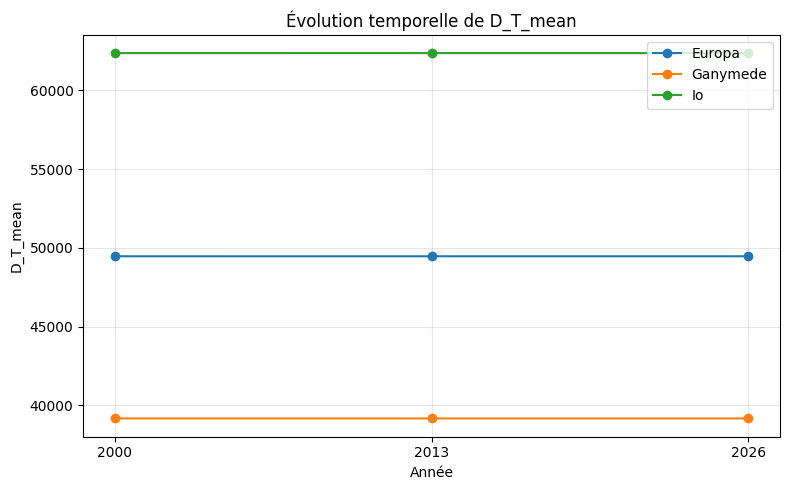

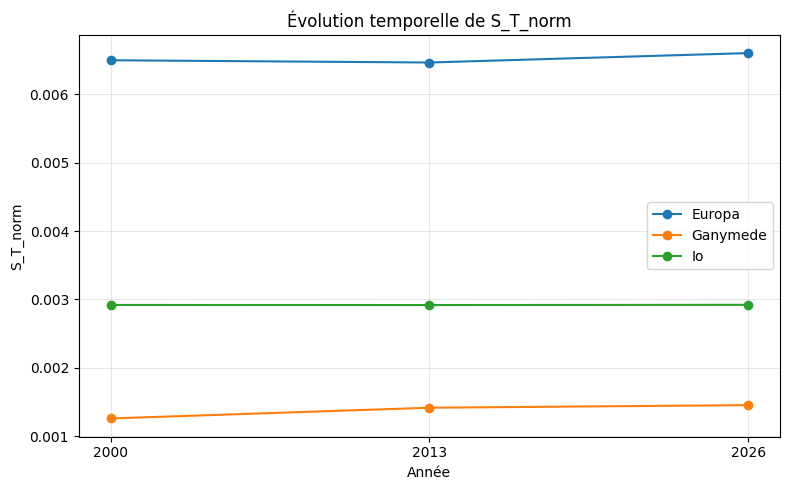

In [ ]:
import matplotlib.pyplot as plt

observables_a_tracer = [
    "D_T_mean",
    "S_T_norm",
    "R_super",
    "theta_mean",
    "theta_std",
    "u_c"
]

for observable in observables_a_tracer:
    plt.figure(figsize=(8, 5))

    for satellite, groupe in observables.groupby("Satellite"):
        groupe = groupe.sort_values("Annee")

        plt.plot(
            groupe["Annee"],
            groupe[observable],
            marker="o",
            label=satellite
        )

    plt.title(f"Évolution temporelle de {observable}")
    plt.xlabel("Année")
    plt.ylabel(observable)
    plt.xticks([2000, 2013, 2026])
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [89]:
display(
    observables[
        ["Satellite", "Annee", "u_c", "R_super", "D_c", "D_T_max"]
    ].sort_values(["Satellite", "Annee"])
)

,Satellite,Annee,u_c,R_super,D_c,D_T_max
0,Europa,2000,0.999597,0.050091,49913.600447,49933.738591
1,Europa,2013,0.999252,0.050000,49910.605201,49947.976791
2,Europa,2026,0.982651,0.050000,49917.132585,49933.483474
3,Ganymede,2000,0.999542,0.050091,39240.176565,39258.161928
4,Ganymede,2013,0.999535,0.050000,39251.224142,39269.493093
5,Ganymede,2026,0.894163,0.050000,39255.279355,39279.164734
6,Io,2000,0.999905,0.050091,62612.723186,62618.652959
7,Io,2013,0.999898,0.050000,62612.512032,62618.923027
8,Io,2026,0.984555,0.050000,62611.516788,62619.610046


In [90]:
observables["u_c_recalcule"] = (
    observables["D_c"] / observables["D_T_max"]
)

observables["ecart_u_c"] = (
    observables["u_c"] - observables["u_c_recalcule"]
)

display(
    observables[
        [
            "Satellite",
            "Annee",
            "u_c",
            "u_c_recalcule",
            "ecart_u_c"
        ]
    ]
)

,Satellite,Annee,u_c,u_c_recalcule,ecart_u_c
0,Europa,2000,0.999597,0.999597,1.110223e-16
1,Europa,2013,0.999252,0.999252,-3.996803e-15
2,Europa,2026,0.982651,0.999673,-1.702133e-02
3,Ganymede,2000,0.999542,0.999542,-2.220446e-16
4,Ganymede,2013,0.999535,0.999535,-7.471801e-14
5,Ganymede,2026,0.894163,0.999392,-1.052285e-01
6,Io,2000,0.999905,0.999905,-2.220446e-16
7,Io,2013,0.999898,0.999898,-7.267520e-13
8,Io,2026,0.984555,0.999871,-1.531619e-02


In [91]:
dossier = Path(
    "/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026"
)

variations_relatives.to_csv(
    dossier / "GVH_Jovian_Variations_Relatives_2000_2026.csv",
    index=False
)

stabilite_gvh.to_csv(
    dossier / "GVH_Jovian_Stabilite_2000_2026.csv",
    index=False
)

resume_observables.to_csv(
    dossier / "GVH_Jovian_Resume_Stabilite_2000_2026.csv",
    index=False
)

print("Exports terminés.")

Exports terminés.


In [92]:
observables["u_c_homogene"] = (
    observables["D_c"] / observables["D_T_max"]
)

In [93]:
observables_analysees_corrigees = [
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_T_max",
    "D_c",
    "u_c_homogene",
    "R_super",
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max"
]

In [94]:
observables = observables.rename(
    columns={"u_c": "u_c_exporte"}
)

observables["u_c_homogene"] = (
    observables["D_c"] / observables["D_T_max"]
)

In [95]:
# ============================================================
# Correction homogène de u_c
# ============================================================

observables = observables.rename(
    columns={"u_c": "u_c_exporte"}
)

observables["u_c_homogene"] = (
    observables["D_c"] / observables["D_T_max"]
)

display(
    observables[
        [
            "Satellite",
            "Annee",
            "u_c_exporte",
            "u_c_homogene"
        ]
    ]
)

,Satellite,Annee,u_c_exporte,u_c_homogene
0,Europa,2000,0.999597,0.999597
1,Europa,2013,0.999252,0.999252
2,Europa,2026,0.982651,0.999673
3,Ganymede,2000,0.999542,0.999542
4,Ganymede,2013,0.999535,0.999535
5,Ganymede,2026,0.894163,0.999392
6,Io,2000,0.999905,0.999905
7,Io,2013,0.999898,0.999898
8,Io,2026,0.984555,0.999871


In [96]:
observables_analysees = [
    "D_T_mean",
    "S_T",
    "S_T_norm",
    "D_T_max",
    "D_c",
    "u_c_homogene",
    "R_super",
    "theta_mean",
    "theta_median",
    "theta_std",
    "theta_max"
]

variations_corrigees = []

for satellite, groupe in observables.groupby("Satellite"):
    groupe = groupe.set_index("Annee").sort_index()

    for observable in observables_analysees:
        v2000 = groupe.loc[2000, observable]
        v2013 = groupe.loc[2013, observable]
        v2026 = groupe.loc[2026, observable]

        variations_corrigees.append({
            "Satellite": satellite,
            "Observable": observable,
            "Delta_2000_2013_pct":
                100 * (v2013 - v2000) / v2000,
            "Delta_2013_2026_pct":
                100 * (v2026 - v2013) / v2013,
            "Delta_2000_2026_pct":
                100 * (v2026 - v2000) / v2000
        })

variations_relatives_corrigees = pd.DataFrame(
    variations_corrigees
)

display(
    variations_relatives_corrigees.sort_values(
        ["Satellite", "Observable"]
    )
)

,Satellite,Observable,Delta_2000_2013_pct,Delta_2013_2026_pct,Delta_2000_2026_pct
3,Europa,D_T_max,0.028514,-0.029017,-0.000511
0,Europa,D_T_mean,0.001516,0.000531,0.002047
4,Europa,D_c,-0.006001,0.013078,0.007077
6,Europa,R_super,-0.181818,0.000000,-0.181818
1,Europa,S_T,-0.478110,1.130420,0.646905
2,Europa,S_T_norm,-0.506480,2.126792,1.609541
10,Europa,theta_max,0.029718,-0.030259,-0.000550
7,Europa,theta_mean,0.001373,0.000464,0.001837
8,Europa,theta_median,0.001714,0.001757,0.003471
9,Europa,theta_std,-0.483247,1.149839,0.661035


In [97]:
stabilite_corrigee = []

for satellite, groupe in observables.groupby("Satellite"):
    for observable in observables_analysees:
        valeurs = groupe[observable].astype(float)

        moyenne = valeurs.mean()
        ecart_type = valeurs.std(ddof=1)

        cv_pct = (
            100 * ecart_type / abs(moyenne)
            if moyenne != 0
            else float("nan")
        )

        amplitude_pct = (
            100 * (valeurs.max() - valeurs.min()) / abs(moyenne)
            if moyenne != 0
            else float("nan")
        )

        stabilite_corrigee.append({
            "Satellite": satellite,
            "Observable": observable,
            "Moyenne": moyenne,
            "Ecart_type": ecart_type,
            "CV_pct": cv_pct,
            "Amplitude_relative_pct": amplitude_pct
        })

stabilite_gvh_corrigee = pd.DataFrame(
    stabilite_corrigee
)

stabilite_gvh_corrigee["Classe_stabilite"] = (
    stabilite_gvh_corrigee["CV_pct"]
    .apply(classer_stabilite)
)

display(
    stabilite_gvh_corrigee.sort_values(
        ["CV_pct", "Satellite"]
    )
)

,Satellite,Observable,Moyenne,Ecart_type,CV_pct,Amplitude_relative_pct,Classe_stabilite
18,Ganymede,theta_mean,2.096568,0.000003,0.000157,0.000306,extrêmement stable
11,Ganymede,D_T_mean,39166.955133,0.101447,0.000259,0.000475,extrêmement stable
22,Io,D_T_mean,62356.359547,0.205670,0.000330,0.000602,extrêmement stable
29,Io,theta_mean,8.478721,0.000028,0.000334,0.000592,extrêmement stable
32,Io,theta_max,8.514415,0.000067,0.000784,0.001420,extrêmement stable
25,Io,D_T_max,62619.062010,0.493448,0.000788,0.001528,extrêmement stable
30,Io,theta_median,8.478561,0.000075,0.000886,0.001768,extrêmement stable
7,Europa,theta_mean,4.224012,0.000040,0.000955,0.001836,extrêmement stable
26,Io,D_c,62612.250669,0.644268,0.001029,0.001927,extrêmement stable
0,Europa,D_T_mean,49460.247920,0.525418,0.001062,0.002047,extrêmement stable


In [98]:
resume_stabilite_corrige = (
    stabilite_gvh_corrigee
    .groupby("Observable", as_index=False)
    .agg(
        CV_moyen_pct=("CV_pct", "mean"),
        CV_max_pct=("CV_pct", "max"),
        Amplitude_moyenne_pct=(
            "Amplitude_relative_pct",
            "mean"
        )
    )
    .sort_values("CV_moyen_pct")
    .reset_index(drop=True)
)

resume_stabilite_corrige["Classe_globale"] = (
    resume_stabilite_corrige["CV_moyen_pct"]
    .apply(classer_stabilite)
)

display(resume_stabilite_corrige)

,Observable,CV_moyen_pct,CV_max_pct,Amplitude_moyenne_pct,Classe_globale
0,theta_mean,0.000482,0.000955,0.000911,extrêmement stable
1,D_T_mean,0.000550,0.001062,0.001041,extrêmement stable
2,theta_median,0.001251,0.001735,0.002478,extrêmement stable
3,D_c,0.009163,0.019915,0.017828,extrêmement stable
4,u_c_homogene,0.010905,0.022437,0.020185,très stable
5,theta_max,0.014644,0.025830,0.027781,très stable
6,D_T_max,0.014723,0.026770,0.028012,très stable
7,R_super,0.105100,0.105100,0.182039,stable
8,S_T,2.729254,7.431587,5.136616,modérément variable
9,theta_std,2.800385,7.633410,5.310303,modérément variable


In [99]:
from pathlib import Path

dossier = Path(
    "/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026"
)

observables.to_csv(
    dossier / "GVH_Jovian_Observables_Homogenees_2000_2026.csv",
    index=False
)

variations_relatives_corrigees.to_csv(
    dossier / "GVH_Jovian_Variations_Relatives_Corrigees_2000_2026.csv",
    index=False
)

stabilite_gvh_corrigee.to_csv(
    dossier / "GVH_Jovian_Stabilite_Corrigee_2000_2026.csv",
    index=False
)

resume_stabilite_corrige.to_csv(
    dossier / "GVH_Jovian_Resume_Stabilite_Corrige_2000_2026.csv",
    index=False
)

print("Exports corrigés terminés.")

Exports corrigés terminés.


In [100]:
from pathlib import Path

dossier = Path(
    "/content/drive/MyDrive/GVH_Jovian_Comparison_2000_2026"
)

observables.to_csv(
    dossier / "GVH_Jovian_Observables_Homogenees_2000_2026.csv",
    index=False
)

variations_relatives_corrigees.to_csv(
    dossier / "GVH_Jovian_Variations_Relatives_Corrigees_2000_2026.csv",
    index=False
)

stabilite_gvh_corrigee.to_csv(
    dossier / "GVH_Jovian_Stabilite_Corrigee_2000_2026.csv",
    index=False
)

resume_stabilite_corrige.to_csv(
    dossier / "GVH_Jovian_Resume_Stabilite_Corrige_2000_2026.csv",
    index=False
)

print("Exports finaux terminés.")

Exports finaux terminés.


# Conclusion — Benchmark temporel GVH des satellites joviens

La comparaison des observables GVH d’Io, Europa et Ganymède aux époques 2000, 2013 et 2026 montre une forte stabilité temporelle des descripteurs centraux.

Les observables `theta_mean`, `D_T_mean`, `theta_median` et `D_c` présentent des coefficients de variation extrêmement faibles. Les paramètres `u_c_homogene`, `theta_max` et `D_T_max` restent également très stables.

Chaque satellite conserve ainsi une signature GVH distincte sur les trois époques :

- Io possède les valeurs les plus élevées de `D_T_mean` et `theta_mean`;
- Europa présente des valeurs intermédiaires;
- Ganymède possède les valeurs les plus faibles.

Les principales variations concernent les mesures de dispersion `S_T`, `S_T_norm` et `theta_std`, particulièrement pour Ganymède. Ces variations relatives doivent toutefois être interprétées avec prudence, car les valeurs absolues restent faibles.

Le paramètre `u_c` exporté dans les fichiers 2026 n’était pas directement comparable aux années précédentes. Une définition homogène a donc été reconstruite :

\[
u_c^{homogene} = \frac{D_c}{D_{T,\max}}
\]

Après correction, ce paramètre devient lui aussi très stable.

Ce benchmark établit donc une robustesse descriptive temporelle des observables GVH sur la période 2000–2026. Il ne constitue pas encore une prédiction physique indépendante, mais fournit une base méthodologique solide pour des comparaisons futures, notamment avec Callisto ou d’autres systèmes orbitaux.